# Relatório CTF – Enumeração de IDs com Hash MD5 (IDOR)

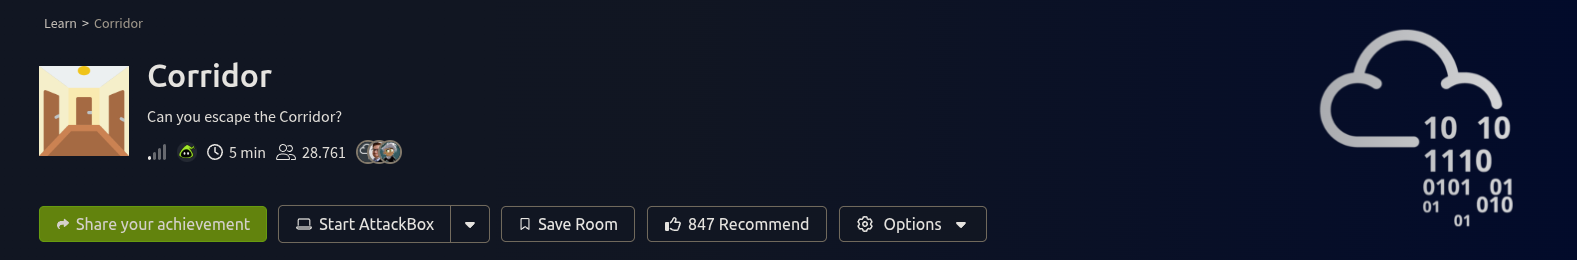

## Contexto
Durante a análise da aplicação web, não foram encontrados diretórios sensíveis por enumeração inicial. 
Ao navegar manualmente pelo site, foi identificado um padrão curioso: um corredor com várias “portas”, onde cada URL continha um valor hexadecimal aparentemente aleatório.

Exemplo:

[http://10.66.159.209/c4ca4238a0b923820dcc509a6f75849b]()


---

## Identificação do Padrão

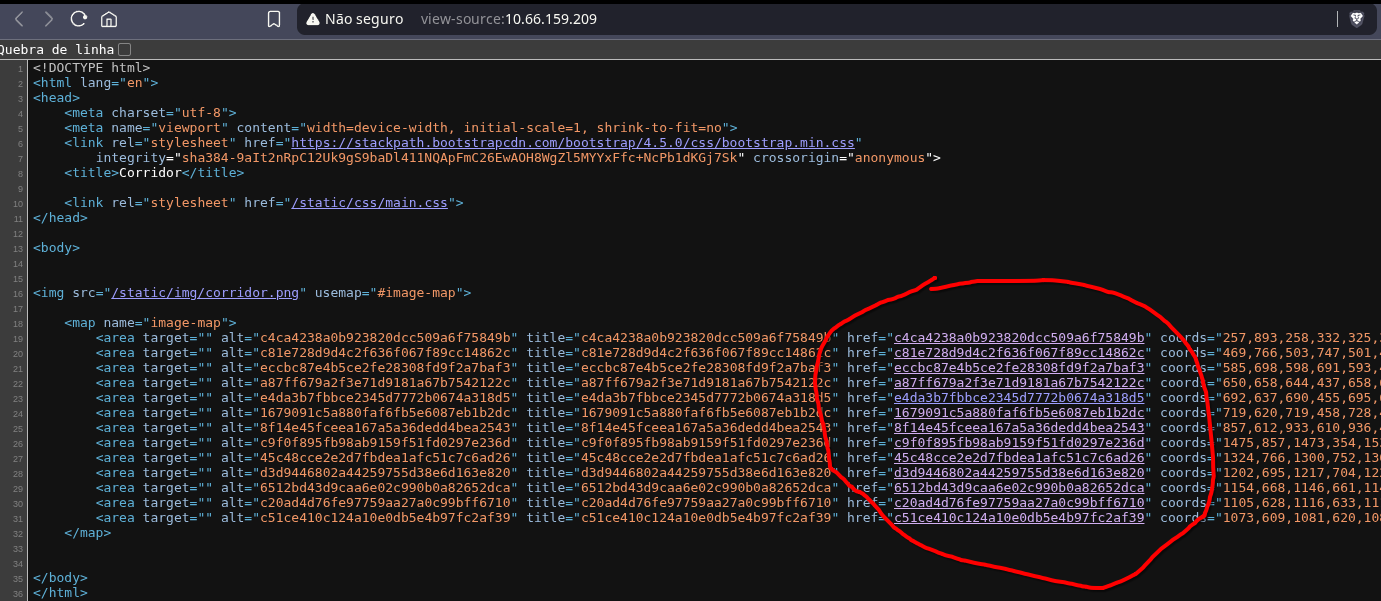


Após coletar várias URLs, observou-se que todos os valores tinham **32 caracteres hexadecimais**, indicando fortemente o uso de **MD5**.

Ao testar hashes conhecidos, confirmou-se o padrão:

| Valor | MD5 |
|-----|----|
| 1 | c4ca4238a0b923820dcc509a6f75849b |
| 2 | c81e728d9d4c2f636f067f89cc14862c |
| 3 | eccbc87e4b5ce2fe28308fd9f2a7baf3 |
| ... | ... |

Ou seja, o sistema estava utilizando `MD5(ID)` diretamente na URL para identificar os recursos.

---

## Tentativas Iniciais
Foram testados:
- Sequência de IDs existentes
- Hashes de `14` a `20`
- Strings comuns (`admin`, `login`)
- Enumeração via `ffuf`

Nenhuma dessas tentativas revelou conteúdo sensível inicialmente.

---

## Descoberta Crítica (IDOR)
Ao testar manualmente o valor **0**, foi gerado o hash:



**MD5("0")** = cfcd208495d565ef66e7dff9f98764da

URL testada:

[http://10.66.159.209/cfcd208495d565ef66e7dff9f98764da]()

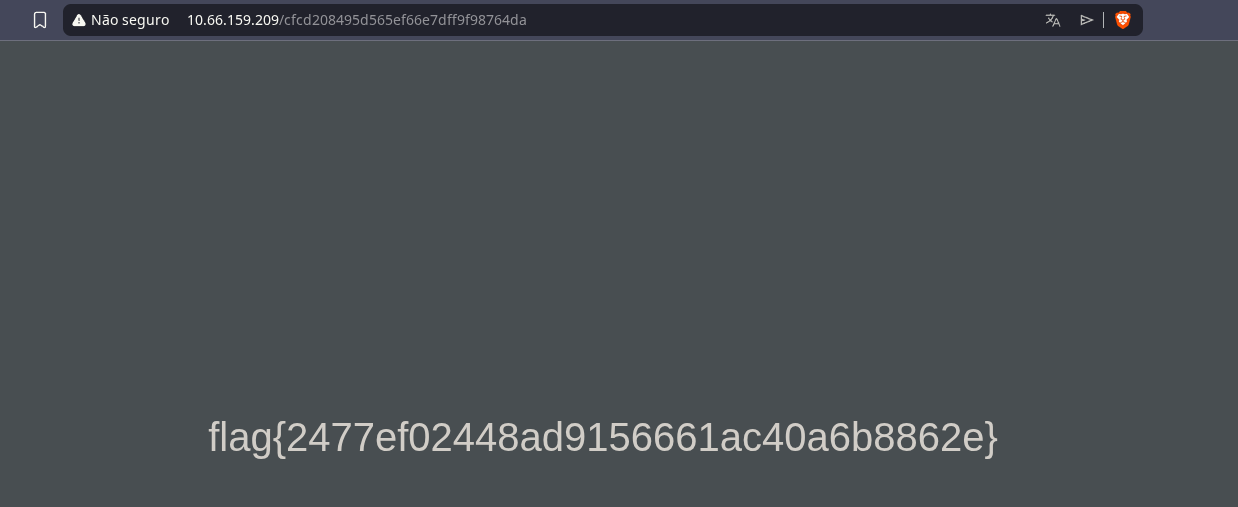


Resultado:
- **Acesso válido**
- Diferente das demais portas vazias

Isso confirmou uma **falha de IDOR (Insecure Direct Object Reference)**, onde:
- O backend confia cegamente no ID
- Não há validação de autorização
- O uso de MD5 é apenas uma obfuscação fraca

---

## Impacto
- Qualquer usuário pode acessar recursos internos apenas calculando o MD5 do ID
- Possibilidade de acesso a:
  - Dados administrativos
  - Flags
  - Conteúdos não autorizados

---

## Conclusão
Este desafio explora um erro clássico:
- Uso incorreto de hash como mecanismo de segurança
- Falta de controle de acesso
- Enumeração previsível de identificadores

A tentativa do valor **0** foi decisiva, pois é um truque comum em CTFs e frequentemente esquecido por desenvolvedores.

---

## Lições Aprendidas
- Hash **não é controle de acesso**
- Sempre testar:
  - ID `0`
  - IDs negativos
  - Valores fora do intervalo esperado
- Em CTFs, padrões simples costumam esconder a flag

---

## Status
- Vulnerabilidade identificada com sucesso
- Vetor explorado: **IDOR via MD5**
- Próximo passo: enumeração completa para localização da flag final


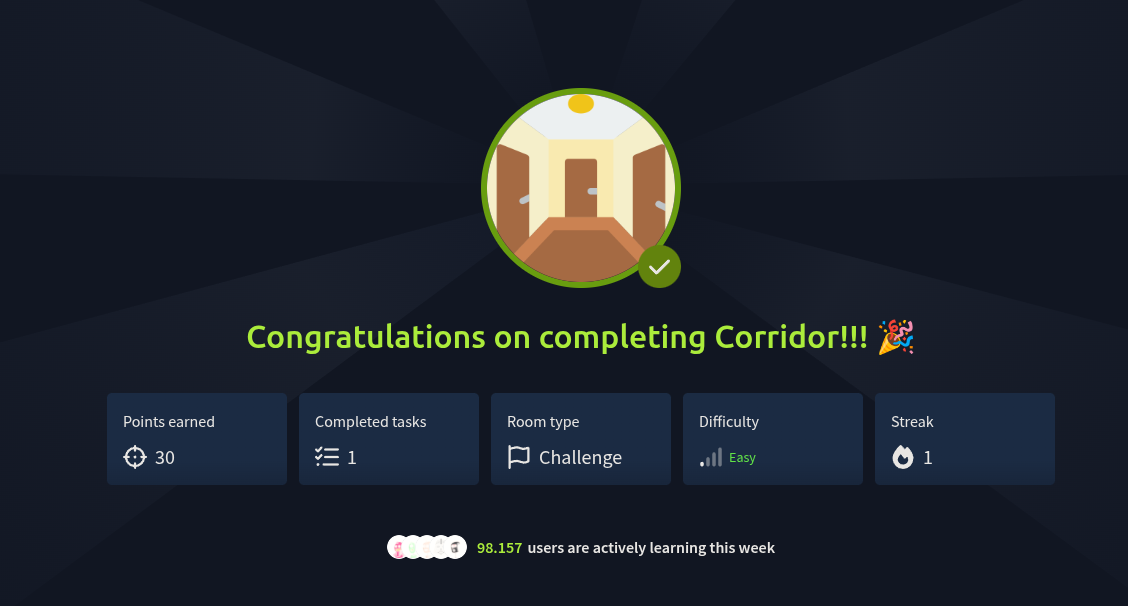